# Data Cleaning and Visualization  - Student Placement Dataset

## Loading the Dataset

The dataset is loaded into a Pandas DataFrame to begin the data cleaning process.

In [1]:
import pandas as pd

df = pd.read_csv("student_placement_prediction_dataset_2026.csv")
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


## Dataset Size

The shape of the dataset is checked to determine the number of rows and columns.

In [2]:
df.shape

(100000, 26)

## Dataset Structure

The dataset structure is examined to understand data types and verify if any columns contain missing values.

In [3]:
df.info(

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

## Removing Irrelevant Columns

The `student_id` column is removed as it does not contribute to analysis or prediction.

In [4]:
df.drop(columns=["student_id"], inplace=True)

## Updated Dataset Structure

The dataset structure is rechecked after removing unnecessary columns.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   age                        100000 non-null  int64  
 1   gender                     100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   branch                     100000 non-null  object 
 4   college_tier               100000 non-null  object 
 5   internships_count          100000 non-null  int64  
 6   projects_count             100000 non-null  int64  
 7   certifications_count       100000 non-null  int64  
 8   coding_skill_score         100000 non-null  float64
 9   aptitude_score             100000 non-null  float64
 10  communication_skill_score  100000 non-null  float64
 11  logical_reasoning_score    100000 non-null  float64
 12  hackathons_participated    100000 non-null  int64  
 13  github_repos               100

## Duplicate Check

The dataset is checked for duplicate records to ensure data integrity.

In [6]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.

## Categorical Encoding

Categorical variables are converted into numerical format using one-hot encoding.

To avoid multicollinearity, `drop_first=True` is used.

In [7]:
df = pd.get_dummies(df, drop_first=True)

## Encoded Dataset

All categorical variables have been successfully converted into numerical format, making the dataset suitable for machine learning models.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   age                        100000 non-null  int64  
 1   cgpa                       100000 non-null  float64
 2   internships_count          100000 non-null  int64  
 3   projects_count             100000 non-null  int64  
 4   certifications_count       100000 non-null  int64  
 5   coding_skill_score         100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skill_score  100000 non-null  float64
 8   logical_reasoning_score    100000 non-null  float64
 9   hackathons_participated    100000 non-null  int64  
 10  github_repos               100000 non-null  int64  
 11  linkedin_connections       100000 non-null  int64  
 12  mock_interview_score       100000 non-null  float64
 13  attendance_percentage      100

## Converting Boolean Columns to Integer

After applying one-hot encoding, several columns were created with boolean (`True/False`) values.

To ensure consistency and compatibility with machine learning models, these boolean columns were converted into integer format:
- `True → 1`
- `False → 0`

This step helps in improving model performance and ensures all features are in numerical format.

In [9]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

## Updated Data Types

After conversion, all categorical features are now represented as numerical values.

The dataset now consists entirely of numerical columns (`int` and `float`), making it fully suitable for analysis and machine learning algorithms.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   age                        100000 non-null  int64  
 1   cgpa                       100000 non-null  float64
 2   internships_count          100000 non-null  int64  
 3   projects_count             100000 non-null  int64  
 4   certifications_count       100000 non-null  int64  
 5   coding_skill_score         100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skill_score  100000 non-null  float64
 8   logical_reasoning_score    100000 non-null  float64
 9   hackathons_participated    100000 non-null  int64  
 10  github_repos               100000 non-null  int64  
 11  linkedin_connections       100000 non-null  int64  
 12  mock_interview_score       100000 non-null  float64
 13  attendance_percentage      100

## Statistical Summary

Descriptive statistics are used to understand the distribution and range of numerical features such as CGPA.

In [11]:
df["cgpa"].describe()

count    100000.000000
mean          7.496890
std           0.992834
min           4.500000
25%           6.820000
50%           7.500000
75%           8.180000
max          10.000000
Name: cgpa, dtype: float64

## Entire Statistical Summary
Descriptive statistics are used to understand the distribution and range of numerical features 

In [12]:
df.describe()

,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,...,gender_Male,branch_Civil,branch_ECE,branch_EEE,branch_IT,branch_Mechanical,college_tier_Tier 2,college_tier_Tier 3,volunteer_experience_Yes,placement_status_Placed
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,1.000690,...,0.600280,0.100210,0.149080,0.101770,0.199990,0.100770,0.499550,0.298840,0.400370,0.54459
std,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,0.997908,...,0.489843,0.300281,0.356169,0.302347,0.399994,0.301025,0.500002,0.457752,0.489976,0.49801
min,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000
75%,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,2.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000
max,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,8.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Saving the Cleaned Dataset

After completing all data cleaning and preprocessing steps, the final dataset was saved as a CSV file.

The dataset is stored as `cleaned_dataset.csv` to ensure it can be reused for further analysis and machine learning tasks without repeating the cleaning process.

The `index=False` parameter is used to prevent saving the DataFrame index as an extra column in the file.

In [13]:
df.to_csv("cleaned_dataset.csv", index=False)

## Final Dataset Shape

The final cleaned dataset contains 100,000 rows and 30 columns.

This confirms that all preprocessing steps were successfully applied without any unintended data loss.

The dataset is now fully prepared for exploratory data analysis and machine learning tasks.

In [15]:
df.shape

(100000, 30)

# Data Visualization and Insights

## CGPA Distribution

This visualization shows how CGPA values are distributed among students.

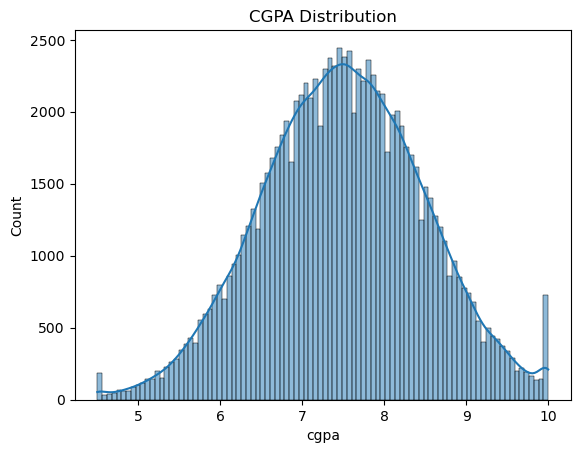

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["cgpa"], kde=True)
plt.title("CGPA Distribution")
plt.show()

The majority of students have CGPA between 7 and 8, indicating average academic performance.

The distribution appears approximately normal, with fewer students having very low or very high CGPA.

## Placement Status Distribution

This graph shows the number of students who are placed versus not placed.

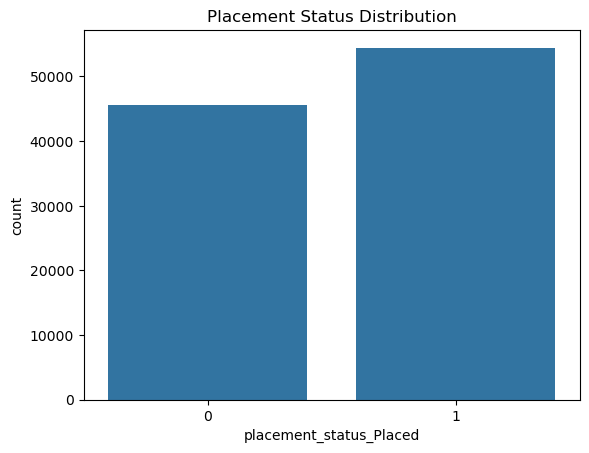

In [19]:
sns.countplot(x=df["placement_status_Placed"])
plt.title("Placement Status Distribution")
plt.show()

The dataset shows a slightly higher number of placed students compared to non-placed students.

This indicates a relatively balanced dataset for placement prediction.

## CGPA vs Placement

This visualization compares CGPA values between placed and non-placed students.

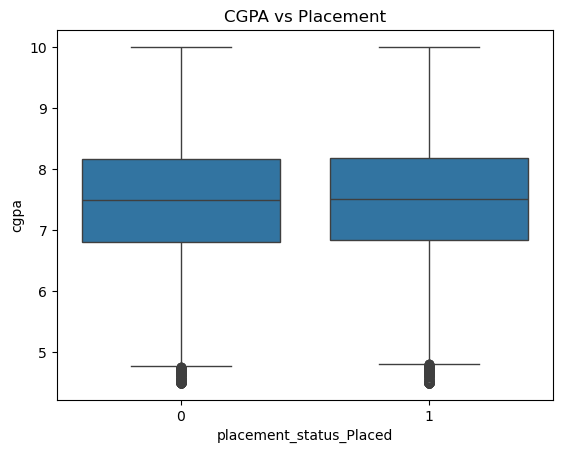

In [20]:
sns.boxplot(x=df["placement_status_Placed"], y=df["cgpa"])
plt.title("CGPA vs Placement")
plt.show()

Students who are placed generally tend to have higher CGPA compared to those who are not placed.

This suggests that CGPA plays an important role in determining placement outcomes.

## Gender Distribution among Placed Students

This pie chart shows the proportion of male and female students among those who were placed.

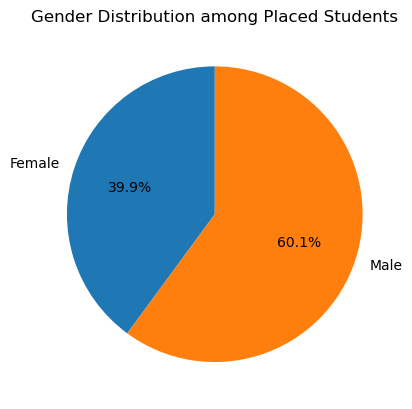

In [31]:
import matplotlib.pyplot as plt

placed_df = df[df["placement_status_Placed"] == 1]


gender_counts = placed_df["gender_Male"].value_counts().sort_index()


labels = ["Female", "Male"]


plt.pie(gender_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Gender Distribution among Placed Students")

plt.show()

The placement distribution between male and female students appears relatively balanced, indicating no strong gender dominance in placement outcomes.

# Final Summary and Insights

This project focused on cleaning, transforming, and analyzing a student placement dataset to understand key factors influencing placement outcomes.

## Data Preparation

The dataset was thoroughly examined to ensure data quality and consistency.  
No missing values or duplicate records were found, indicating a clean and reliable dataset.

Irrelevant features such as `student_id` were removed, as they do not contribute to analysis or prediction.  
Categorical variables were converted into numerical format using one-hot encoding, and boolean values were transformed into integers to ensure compatibility with analytical and machine learning processes.

## Key Observations from Data Visualization

The visual analysis provided several meaningful insights:

- **Academic Performance (CGPA):**  
  Most students have CGPA values between 7 and 8, indicating a moderate level of academic performance across the dataset.

- **Placement Distribution:**  
  A slightly higher proportion of students are placed, suggesting a reasonable placement rate.

- **CGPA vs Placement:**  
  Students with higher CGPA tend to have better placement outcomes, indicating that academic performance plays a significant role in securing placements.

- **Gender Analysis:**  
  The distribution of male and female students among placed candidates is relatively balanced, suggesting that gender does not significantly influence placement outcomes.

## Conclusion

Overall, the dataset is clean, well-structured, and suitable for further analysis.  
The insights indicate that academic performance is a key factor in placement success, while gender does not appear to have a strong impact.

The dataset is now fully prepared for deeper exploratory analysis and predictive modeling in subsequent tasks.